# MLPR LAB 14
### Proshita Agarwal

In [30]:
# step 1: Import Libraries

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model

In [84]:
#step 2 & 3: load dataset

DATASET_PATH = "IndianCurrencyNotesDataset/AllImages"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=50,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=50,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
print(class_names)

Found 178 files belonging to 7 classes.
Using 143 files for training.


Found 178 files belonging to 7 classes.
Using 35 files for validation.
['10 Note', '100 Note', '20 Note', '200 Note', '2000 Note', '50 Note', '500 Note']


In [85]:
#data augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1)
])

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x), y)
)

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

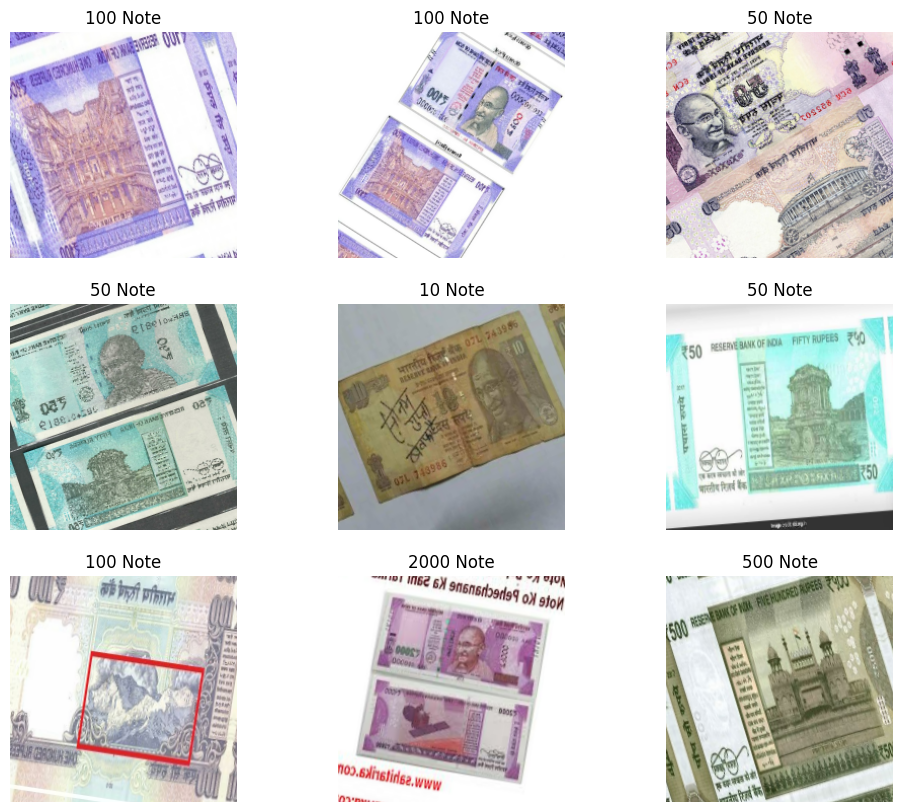

In [86]:
#display sample images

plt.figure(figsize=(12, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [87]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    pooling='avg',
    input_shape=(224, 224, 3)
)
base_model.trainable = False

In [88]:
X_train_features = []
y_train = []

for images, labels in train_dataset:
    images = preprocess_input(images)
    features = base_model.predict(images, verbose=0)
    X_train_features.append(features)
    y_train.append(labels.numpy())
X_train_features = np.concatenate(X_train_features)
y_train = np.concatenate(y_train)

print(X_train_features.shape)

(143, 2048)


In [89]:
X_test_features = []
y_test = []

for images, labels in test_dataset:
    images = preprocess_input(images)
    features = base_model.predict(images, verbose=0)
    X_test_features.append(features)
    y_test.append(labels.numpy())

X_test_features = np.concatenate(X_test_features)
y_test = np.concatenate(y_test)

In [90]:
svm_classifier = SVC(kernel='rbf')
svm_classifier.fit(X_train_features, y_train)

y_pred = svm_classifier.predict(X_test_features)

In [91]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

Accuracy: 0.8285714285714286

Classification Report:

              precision    recall  f1-score   support

     10 Note       0.75      1.00      0.86         3
    100 Note       0.50      0.60      0.55         5
     20 Note       1.00      1.00      1.00         6
    200 Note       1.00      0.80      0.89         5
   2000 Note       1.00      0.80      0.89         5
     50 Note       0.83      0.71      0.77         7
    500 Note       0.80      1.00      0.89         4

    accuracy                           0.83        35
   macro avg       0.84      0.84      0.83        35
weighted avg       0.85      0.83      0.83        35



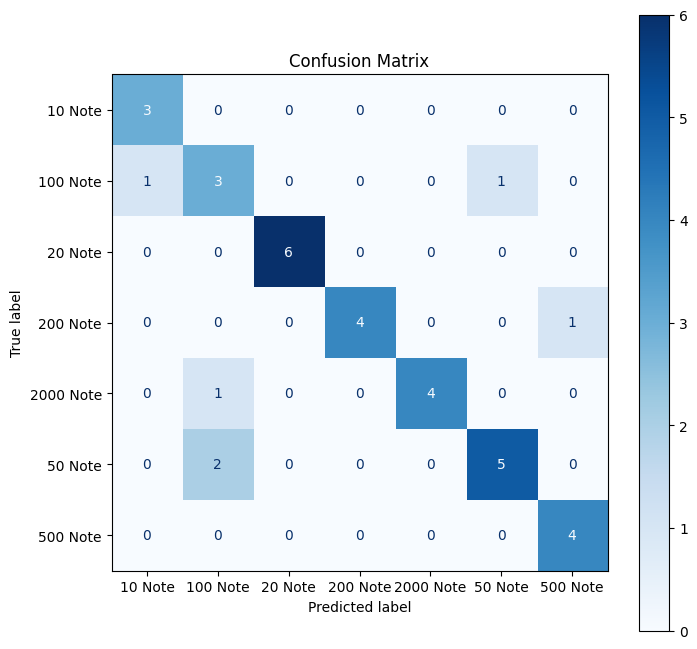

In [92]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

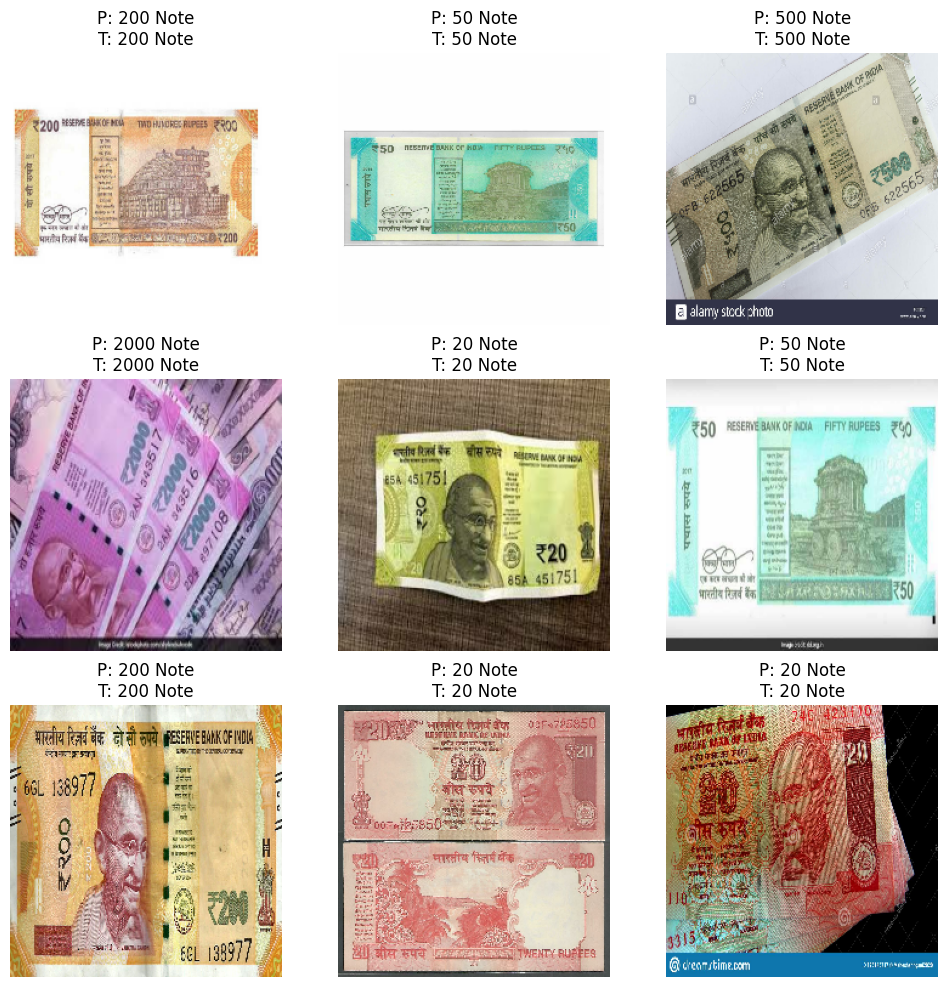

In [93]:
plt.figure(figsize=(12, 12))

for images, labels in test_dataset.take(1):
    predictions = svm_classifier.predict(
        base_model.predict(
            preprocess_input(images),
            verbose=0
        )
    )
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        pred_label = class_names[predictions[i]]
        true_label = class_names[labels[i]]
        plt.title(f"P: {pred_label}\nT: {true_label}")
        plt.axis("off")
plt.show()

# Report

### 1. What were the main innovations in ResNet and GoogLeNet?

ResNet:

The main innovation in ResNet was the use of residual or skip connections. These connections allow the input to skip some layers and directly reach deeper layers. This helps solve the vanishing gradient problem and makes it possible to train very deep neural networks properly.

GoogLeNet

GoogLeNet introduced the inception module, where different convolution filters like 1×1, 3×3, and 5×5 are used together in parallel. This helps the network capture different types of features while also reducing computation.


### 2. Why do we at times need Transfer Learning?

We use Transfer Learning when we do not have a very large dataset or enough time and resources to train a deep learning model from scratch. A pretrained model has already learned useful features from millions of images, so we can use that knowledge for our own task. This improves accuracy and reduces training time.


### 3. How can up sampling training set help with Transfer Learning?

Up sampling helps by increasing the number of training samples, especially for classes that have fewer images. This makes the dataset more balanced and helps the model learn all classes properly. It can improve the overall performance and accuracy of the model.



### 4. Are there any limitations of using Transfer Learning? List only two.

1. Transfer Learning may not work well if the new dataset is very different from the dataset on which the original model was trained.

2. Some pretrained models are large and require high memory and computational power.



### 5. What are the different approaches in Transfer Learning?

1. **Feature Extraction** – The pretrained model is used only for extracting features, and another classifier is trained on those features.

2. **Fine Tuning** – Some layers of the pretrained model are retrained on the new dataset to improve performance.

3. **Domain Adaptation** – Knowledge from one domain is transferred to another related domain.

4. **Multi-task Learning** – A single model learns multiple related tasks together so that learning one task helps improve the others.
